#### Faulty Netlist to Graph generation

In [1]:
# build_csv_with_fault_topology.py
"""
Create nodes.csv and edges.csv but this time we EMBED the injected faults into the graph:
 - Stuck-at: create pseudo source node SA0_<net> / SA1_<net> that overrides driver(net)
 - Bridging: create pseudo node BR_<n1>_<n2>, add it as driver(n1), and connect driver(n2) -> BR node
 - Glitch:   create pseudo source node GL_<net> (stores delays as attributes), overrides driver(net)

Labels:
 - label=1 only for the pseudo fault node we create; others 0.

This produces structural differences so SCOAP, degrees, and distances will reflect the faults.
"""

import re
import csv
from pathlib import Path
from collections import defaultdict

SRC_DIR    = Path("verilog_benchmark_circuits")   # clean originals
FAULT_DIRS = {"stuck_at": Path("stuck_at"),
              "glitch"  : Path("glitch"),
              "bridging": Path("bridging")}
OUT_NODE   = Path("nodes.csv")
OUT_EDGE   = Path("edges.csv")

# ---------- regex ----------
COMMENT_RE    = re.compile(r'//.*')
MODULE_RE     = re.compile(r'\bmodule\b.*?\bendmodule\b', re.DOTALL)
PORT_DECL_RE  = re.compile(r'\b(input|output)\b\s+([^;]+);')
NET_DECL_RE   = re.compile(r'\b(wire|reg)\b\s+([^;]+);')
INST_RE       = re.compile(r'^\s*([A-Za-z_]\w*)\s+([A-Za-z_]\w*)\s*\(\s*(.*?)\s*\)\s*$', re.DOTALL)
PORT_MAP_RE   = re.compile(r'\.(\w+)\s*\(\s*([\w\[\]\\]+)\s*\)')
ID_RE         = re.compile(r'(\\[^\s]+\s|[A-Za-z_]\w*)')
OUT_PORTS     = {"Y","ZN","Z","Q","O","CO","S","SUM"}

# fault regex
ASSIGN_CONST_RE = re.compile(r'assign\s+([\w\[\]\\]+)\s*=\s*1\'b([01])\s*;', re.IGNORECASE)
ASSIGN_BRIDGE_RE = re.compile(r'assign\s+([\w\[\]\\]+)\s*=\s*([\w\[\]\\]+)\s*;', re.IGNORECASE)
GLITCH_BLOCK_RE = re.compile(r'initial\s*begin(.*?)end', re.IGNORECASE | re.DOTALL)
GLITCH_TOGGLE_RE = re.compile(r'#\s*(\d+)\s+([\w\[\]\\]+)\s*=\s*~\s*\2\s*;')

def strip_comments(txt: str) -> str:
    return COMMENT_RE.sub("", txt)

def extract_module(txt: str) -> str:
    m = MODULE_RE.search(txt)
    return m.group(0) if m else ""

def find_ids(s: str):
    return [m.group(1).rstrip() for m in ID_RE.finditer(s)]

def parse_named_ports(s: str):
    return {m.group(1): m.group(2).rstrip() for m in PORT_MAP_RE.finditer(s)}

def parse_instances(body: str):
    """Return gates, driver, loads from instance connections only (no assigns)."""
    gates  = {}             # inst -> gate_type
    driver = {}             # net -> inst (output driver)
    loads  = defaultdict(list)  # net -> [insts that read the net]

    tmp = re.sub(r'\((.*?)\)', lambda x: x.group(0).replace('\n',' '), body, flags=re.DOTALL)
    for stmt in tmp.split(';'):
        stmt = stmt.strip()
        if not stmt or "(" not in stmt:
            continue
        head = stmt.split()[0]
        if head in {"module","endmodule","input","output","wire","reg","assign"}:
            continue
        m = INST_RE.match(stmt)
        if not m:
            continue
        gatetype, inst, ports_str = m.groups()
        gates[inst] = gatetype
        if "." in ports_str:
            pm = parse_named_ports(ports_str)
            for p, net in pm.items():
                if p in OUT_PORTS:
                    driver[net] = inst
                else:
                    loads[net].append(inst)
        else:
            tokens = find_ids(ports_str)
            if not tokens:
                continue
            out, ins = tokens[0], tokens[1:]
            driver[out] = inst
            for net in ins:
                loads[net].append(inst)
    return gates, driver, loads

def inject_fault_topology(raw_text: str, ftype: str, gates, driver, loads):
    """
    Mutate (gates, driver, loads) in-place to reflect injected faults.
    We only touch the nets actually mentioned in injected code.
    Returns: list of created pseudo nodes and (optional) per-node attrs dict.
    """
    created_nodes = []
    node_attrs = {}   # name -> dict of attributes (e.g., glitch delays)

    if ftype == "clean":
        return created_nodes, node_attrs

    # We only need to scan the file tail where injection is appended.
    # But to be robust, scan entire text.
    text = raw_text

    # --- stuck-at: assign <net> = 1'b0/1'b1;
    for m in ASSIGN_CONST_RE.finditer(text):
        net = m.group(1)
        val = m.group(2)
        inst = f"SA{val}_{net}"
        gates[inst] = f"sa{val}"  # gate_type
        # override driver(net) with pseudo source
        driver[net] = inst
        # SA node is a pure source; no inputs; its outputs will be wired when edges are created
        created_nodes.append(inst)

    # --- glitch: look for two toggles inside an initial block
    # We create GL_<net> and override driver(net) = GL_<net>
    for blk in GLITCH_BLOCK_RE.finditer(text):
        body = blk.group(1)
        toggles = GLITCH_TOGGLE_RE.findall(body)
        # group by net
        by_net = {}
        for delay, net in toggles:
            by_net.setdefault(net, []).append(int(delay))
        for net, delays in by_net.items():
            if len(delays) >= 1:
                inst = f"GL_{net}"
                gates[inst] = "glitch"
                driver[net] = inst
                created_nodes.append(inst)
                node_attrs[inst] = {"glitch_delays": sorted(delays)}

    # --- bridging: assign n1 = n2; but avoid picking up stuck-at lines (they match too); so filter constants.
    for m in ASSIGN_BRIDGE_RE.finditer(text):
        n1, n2 = m.group(1), m.group(2)
        # skip if RHS is a constant  (handled by stuck-at)
        if re.match(r"1'b[01]$", n2, flags=re.IGNORECASE):
            continue
        # create BR node: input from n2, output drives n1
        inst = f"BR_{n1}_{n2}"
        gates[inst] = "bridge"
        # 1) connect driver(n2) -> BR node by adding BR as a *load* of net n2
        loads[n2].append(inst)
        # 2) BR becomes the driver of n1 (override)
        driver[n1] = inst
        created_nodes.append(inst)

    return created_nodes, node_attrs

def write_graph_csv(netfile: str, ftype: str, raw_text: str, node_w, edge_w):
    # strip comments & isolate module body
    body = extract_module(strip_comments(raw_text))
    if not body:
        return False

    # IO directions to generate PI/PO nodes (optional; we keep gates only here)
    # (Well keep the node set to instances & pseudo nodes; PIs/POs are implicit via zero in/out degrees)
    gates, driver, loads = parse_instances(body)

    # Apply topology edits for injected faults
    created_nodes, node_attrs = inject_fault_topology(raw_text, ftype, gates, driver, loads)

    # Build node set: all instances + pseudo nodes + any loads-only instances we added
    node_set = set(gates.keys())
    # ensure loads-only pseudo nodes are present (e.g., BR)
    for net, dsts in loads.items():
        for inst in dsts:
            if inst not in gates:
                # mark as special if somehow missed
                gates[inst] = "bridge"
                node_set.add(inst)

    # Degrees (compute after connections are defined)
    indeg = {n: 0 for n in node_set}
    outdeg = {n: 0 for n in node_set}

    # For each net, we will write edges: src = driver[net] -> dst in loads[net]
    # Accumulate edges first to count degrees
    edges = []
    for net, src_inst in list(driver.items()):
        dsts = loads.get(net, [])
        for d in dsts:
            if src_inst in node_set and d in node_set:
                edges.append((src_inst, d))
                outdeg[src_inst] += 1
                indeg[d] += 1

    # Labels: only pseudo fault nodes are label=1
    labels = {n: 0 for n in node_set}
    for n in created_nodes:
        labels[n] = 1

    # Write nodes
    # We keep minimal structural columns here; enhanced metrics are computed later by feature_engineer.py
    node_cols = [
        "netlist_file","fault_type","node_id","gate_type",
        "in_degree","out_degree","total_degree",
        "path_depth","CC0","CC1","CO",
        "is_input","is_output","label"
    ]
    # dummy placeholders for path_depth/CC/CO/is_input/is_output (feature_engineer will recompute)
    for n in sorted(node_set):
        node_w.writerow([
            netfile, ftype, n, gates.get(n,"unk"),
            indeg[n], outdeg[n], indeg[n] + outdeg[n],
            0, "", "", "",
            0, 0, labels[n]
        ])

    # fanout per source instance (simple count)
    fanout = defaultdict(int)
    for s, d in edges:
        fanout[s] += 1

    # Write edges
    for s, d in edges:
        edge_w.writerow([netfile, ftype, s, d, fanout[s]])

    return True

def main():
    # reset outputs
    if OUT_NODE.exists(): OUT_NODE.unlink()
    if OUT_EDGE.exists(): OUT_EDGE.unlink()

    with OUT_NODE.open("w", newline="") as nf, OUT_EDGE.open("w", newline="") as ef:
        node_w = csv.writer(nf); edge_w = csv.writer(ef)
        node_w.writerow([
            "netlist_file","fault_type","node_id","gate_type",
            "in_degree","out_degree","total_degree",
            "path_depth","CC0","CC1","CO",
            "is_input","is_output","label"
        ])
        edge_w.writerow(["netlist_file","fault_type","src_node","dst_node","fan_out"])

        # clean originals
        for v in sorted(SRC_DIR.glob("*.v")):
            txt = v.read_text()
            write_graph_csv(v.name, "clean", txt, node_w, edge_w)

        # fault directories
        for ftype, folder in FAULT_DIRS.items():
            if not folder.exists(): 
                continue
            for v in sorted(folder.glob("*.v")):
                txt = v.read_text()
                # strip the leading "ftype_" in filename to keep netlist base aligned
                base = v.name
                prefix = f"{ftype}_"
                if base.startswith(prefix):
                    base = base[len(prefix):]
                write_graph_csv(base, ftype, txt, node_w, edge_w)

    print(f"? Wrote {OUT_NODE} and {OUT_EDGE} with fault-aware topology.")

if __name__ == "__main__":
    main()


? Wrote nodes.csv and edges.csv with fault-aware topology.


#### Generating enhanced nodes and edges csv files from nodes.csv and edges.csv

In [6]:
# feature_engineer.py
"""
Compute enhanced node/edge features from fault-aware nodes.csv / edges.csv:
 - Exact SCOAP CC0 / CC1 / CO (combinational)
 - path_depth (from sources / indegree==0)
 - dist_to_PO (reverse BFS from sinks / outdegree==0)
 - fanout and fanout_norm (per graph)
 - gate_delay (including pseudo gates: sa0/sa1/bridge/glitch)

Inputs:
    nodes.csv  (from build_csv_with_fault_topology.py)
    edges.csv  (same)
Outputs:
    nodes_enhanced.csv
    edges_enhanced.csv
"""

from pathlib import Path
from collections import defaultdict, deque
import math
import csv

import pandas as pd
import numpy as np

# -------- config --------
NODES_CSV = Path("nodes.csv")
EDGES_CSV = Path("edges.csv")
OUT_NODES = Path("nodes_enhanced.csv")
OUT_EDGES = Path("edges_enhanced.csv")

# Gate delays (adjust as needed; pseudo gates included)
GATE_DELAY = {
    "and": 1.0, "nand": 1.0, "or": 1.0, "nor": 1.0,
    "not": 0.5, "inv": 0.5, "buf": 0.5, "buff": 0.5,
    "xor": 2.0, "xnor": 2.0,
    "pi": 0.0, "po": 0.0, "PI": 0.0, "PO": 0.0,
    # pseudo fault sources / elements
    "sa0": 0.0, "sa1": 0.0,         # constants
    "bridge": 0.2,                   # pass-through
    "glitch": 0.2,                   # small source (no fixed timing here)
    "unk": 1.0
}

INF = 10**9

# -------- SCOAP helpers --------
def scoap_cc_for_gate(gtype: str, in_cc0, in_cc1):
    """
    SCOAP controllability (exact for common gates).
    Returns (CC0_out, CC1_out).
    """
    gt = (gtype or "").lower()
    a0 = list(in_cc0)
    a1 = list(in_cc1)

    # Pseudo sources
    if gt == "sa0":
        return 1, INF
    if gt == "sa1":
        return INF, 1
    if gt in ("glitch",):
        # treat as primary source if no inputs; else buffer-like
        if len(a0) == 0:
            return 1, 1
        return 1 + a0[0], 1 + a1[0]
    if gt in ("bridge", "buf", "buff"):
        if len(a0) == 0:
            return 1, 1
        return 1 + a0[0], 1 + a1[0]

    # Inverters/buffers
    if gt in ("not", "inv"):
        if len(a0) == 0:
            return 1, 1
        return 1 + a1[0], 1 + a0[0]

    if gt in ("and",):
        cc0 = 1 + (min(a0) if a0 else 0)
        cc1 = 1 + sum(a1)
        return cc0, cc1

    if gt in ("or",):
        cc0 = 1 + sum(a0)
        cc1 = 1 + (min(a1) if a1 else 0)
        return cc0, cc1

    if gt in ("nand",):
        cc0 = 1 + sum(a1)                 # to drive 0 at NAND out, inputs must be 1
        cc1 = 1 + (min(a0) if a0 else 0)
        return cc0, cc1

    if gt in ("nor",):
        cc0 = 1 + (min(a1) if a1 else 0)
        cc1 = 1 + sum(a0)
        return cc0, cc1

    if gt in ("xor",):
        if len(a0) == 2:
            cc0 = 1 + min(a0[0] + a0[1], a1[0] + a1[1])
            cc1 = 1 + min(a1[0] + a0[1], a0[0] + a1[1])
        else:
            # approximate for >2 inputs
            cc0 = 1 + min(sum(a0), sum(a1))
            cc1 = 1 + min(sum(a0), sum(a1))
        return cc0, cc1

    if gt in ("xnor",):
        if len(a0) == 2:
            cc0 = 1 + min(a1[0] + a0[1], a0[0] + a1[1])
            cc1 = 1 + min(a0[0] + a0[1], a1[0] + a1[1])
        else:
            cc0 = 1 + min(sum(a0), sum(a1))
            cc1 = 1 + min(sum(a0), sum(a1))
        return cc0, cc1

    # Fallback: AND-like conservative
    cc0 = 1 + (min(a0) if a0 else 0)
    cc1 = 1 + sum(a1)
    return cc0, cc1


def scoap_co_for_gate_input(gtype: str, out_co: int, other_cc0, other_cc1):
    """
    Observability for a gate input:
      CO(in_i) = out_co + 1 + sum(CC_noncontrolling(other inputs))
    """
    gt = (gtype or "").lower()

    if gt in ("buf", "buff", "not", "inv", "bridge", "glitch", "sa0", "sa1"):
        # One input (or source): just pass-through cost
        return int(math.ceil(out_co + 1))

    if gt in ("and", "nand"):
        extra = sum(other_cc1)  # non-controlling value = 1
        return int(math.ceil(out_co + 1 + extra))

    if gt in ("or", "nor"):
        extra = sum(other_cc0)  # non-controlling value = 0
        return int(math.ceil(out_co + 1 + extra))

    if gt in ("xor", "xnor"):
        # need specific pattern on other inputs; use min(CC0, CC1)
        extra = sum(min(a, b) for a, b in zip(other_cc0, other_cc1))
        return int(math.ceil(out_co + 1 + extra))

    # Fallback
    extra = sum(min(a, b) for a, b in zip(other_cc0, other_cc1))
    return int(math.ceil(out_co + 1 + extra))


# -------- main pipeline --------
def build_struct(nodes_df, edges_df):
    """
    Build per-(netlist_file, fault_type) adjacency and metadata.
    """
    graphs = {}
    for (nf, ft), gnodes in nodes_df.groupby(["netlist_file", "fault_type"], sort=False):
        node_ids = gnodes["node_id"].tolist()
        gate_type = dict(zip(gnodes["node_id"], gnodes["gate_type"]))
        label_map = dict(zip(gnodes["node_id"], gnodes["label"]))

        sube = edges_df[(edges_df["netlist_file"] == nf) & (edges_df["fault_type"] == ft)]
        succ = defaultdict(list)
        pred = defaultdict(list)
        for _, row in sube.iterrows():
            s = row["src_node"]; d = row["dst_node"]
            if s in gate_type and d in gate_type:
                succ[s].append(d)
                pred[d].append(s)

        # in/out degrees from adjacency
        indeg = {n: len(pred[n]) for n in node_ids}
        outdeg = {n: len(succ[n]) for n in node_ids}
        fanout = {n: len(succ[n]) for n in node_ids}

        graphs[(nf, ft)] = {
            "nodes": node_ids,
            "gate_type": gate_type,
            "label": label_map,
            "succ": succ,
            "pred": pred,
            "indeg": indeg,
            "outdeg": outdeg,
            "fanout": fanout
        }
    return graphs


def compute_topology_features(meta):
    nodes = meta["nodes"]; succ = meta["succ"]; pred = meta["pred"]

    # Sources (act like PIs): indegree==0
    sources = [n for n in nodes if len(pred[n]) == 0]
    # Sinks (act like POs): outdegree==0
    sinks = [n for n in nodes if len(succ[n]) == 0]

    # path_depth from sources
    path_depth = {n: 0 for n in sources}
    dq = deque(sources)
    while dq:
        u = dq.popleft()
        for v in succ[u]:
            if v not in path_depth:
                path_depth[v] = path_depth[u] + 1
                dq.append(v)
    if path_depth:
        maxd = max(path_depth.values())
    else:
        maxd = 0
    for n in nodes:
        path_depth.setdefault(n, maxd)

    # dist_to_PO by reverse BFS from sinks
    dist_po = {n: 0 for n in sinks}
    dq = deque(sinks)
    while dq:
        u = dq.popleft()
        for v in pred[u]:
            if v not in dist_po:
                dist_po[v] = dist_po[u] + 1
                dq.append(v)
    if dist_po:
        maxdpo = max(dist_po.values())
    else:
        maxdpo = 0
    for n in nodes:
        dist_po.setdefault(n, maxdpo)

    return sources, sinks, path_depth, dist_po


def compute_scoap(meta, sources):
    nodes = meta["nodes"]; succ = meta["succ"]; pred = meta["pred"]; gate_type = meta["gate_type"]

    # Kahn topological order (best-effort; if cycles exist, fall back to node order)
    indeg_tmp = {n: len(pred[n]) for n in nodes}
    q = deque([n for n in nodes if indeg_tmp[n] == 0])
    topo = []
    while q:
        u = q.popleft()
        topo.append(u)
        for v in succ[u]:
            indeg_tmp[v] -= 1
            if indeg_tmp[v] == 0:
                q.append(v)
    if len(topo) != len(nodes):
        topo = list(nodes)  # fallback if not DAG

    # Forward: CC0/CC1
    cc0 = {n: INF for n in nodes}
    cc1 = {n: INF for n in nodes}
    for p in sources:
        # sources (including sa0/sa1/glitch with indeg==0) behave like PI for baseline
        gt = (gate_type.get(p, "") or "").lower()
        if gt == "sa0":
            cc0[p], cc1[p] = 1, INF
        elif gt == "sa1":
            cc0[p], cc1[p] = INF, 1
        else:
            # glitch/bridge with no inputs are treated as generic source
            cc0[p], cc1[p] = 1, 1

    for n in topo:
        ins = pred[n]
        in_cc0 = [cc0[i] for i in ins]
        in_cc1 = [cc1[i] for i in ins]
        c0, c1 = scoap_cc_for_gate(gate_type.get(n, "unk"), in_cc0, in_cc1)
        # combine with existing (min to be safe if multiple passes)
        cc0[n] = min(cc0[n], c0)
        cc1[n] = min(cc1[n], c1)

    # Backward: CO
    co = {n: INF for n in nodes}
    # Initialize sinks (PO-like) to 0
    sinks = [n for n in nodes if len(succ[n]) == 0]
    for s in sinks:
        co[s] = 0

    # Iterate backwards to propagate CO
    changed = True
    iters = 0
    while changed and iters < 100:
        changed = False
        iters += 1

        # update inputs of each gate from its output CO
        for g in reversed(topo):
            out_co = co[g]
            inputs = pred[g]
            if not inputs:
                continue
            for i_idx, i in enumerate(inputs):
                others = [x for x in inputs if x != i]
                other_cc0 = [cc0[x] for x in others]
                other_cc1 = [cc1[x] for x in others]
                cand = scoap_co_for_gate_input(gate_type.get(g, "unk"), out_co, other_cc0, other_cc1)
                if cand < co[i]:
                    co[i] = cand
                    changed = True

        # also along fanouts: a nodes CO is min(child CO)+1
        for n in nodes:
            if succ[n]:
                best = min(co[ch] for ch in succ[n]) + 1
                if best < co[n]:
                    co[n] = best
                    changed = True

    # sanitize
    for n in nodes:
        if cc0[n] >= INF: cc0[n] = int(1e6)
        if cc1[n] >= INF: cc1[n] = int(1e6)
        if co[n]  >= INF: co[n]  = int(1e6)

    return cc0, cc1, co


def main():
    if not NODES_CSV.exists() or not EDGES_CSV.exists():
        raise SystemExit("nodes.csv or edges.csv not found. Run build_csv_with_fault_topology.py first.")

    nodes_df = pd.read_csv(NODES_CSV)
    edges_df = pd.read_csv(EDGES_CSV)

    # Prepare writers
    if OUT_NODES.exists(): OUT_NODES.unlink()
    if OUT_EDGES.exists(): OUT_EDGES.unlink()

    node_cols = [
        "netlist_file","fault_type","node_id","gate_type",
        "in_degree","out_degree","total_degree",
        "path_depth",
        "CC0_approx","CC1_approx","CO_approx",   # keep columns for compatibility (left blank)
        "CC0_exact","CC1_exact","CO_exact",
        "dist_to_PO",
        "fanout","fanout_norm","gate_delay",
        "label"
    ]

    with OUT_NODES.open("w", newline="") as nf, OUT_EDGES.open("w", newline="") as ef:
        node_w = csv.writer(nf); edge_w = csv.writer(ef)
        node_w.writerow(node_cols)
        edge_w.writerow(["netlist_file","fault_type","src_node","dst_node","fan_out"])

        # Process per graph (netlist_file, fault_type)
        graphs = build_struct(nodes_df, edges_df)

        for (nf, ft), meta in graphs.items():
            nodes = meta["nodes"]; succ = meta["succ"]; pred = meta["pred"]
            indeg = meta["indeg"]; outdeg = meta["outdeg"]; fanout = meta["fanout"]
            gate_type = meta["gate_type"]; labels = meta["label"]

            # topology features
            sources, sinks, path_depth, dist_po = compute_topology_features(meta)

            # SCOAP
            cc0, cc1, co = compute_scoap(meta, sources)

            # fanout normalization within graph
            max_fout = max(fanout.values()) if fanout else 1.0
            if max_fout <= 0: max_fout = 1.0

            # write nodes
            for n in nodes:
                gt = (gate_type.get(n, "unk") or "unk")
                gd = GATE_DELAY.get(gt.lower(), GATE_DELAY["unk"])
                node_w.writerow([
                    nf, ft, n, gt,
                    indeg[n], outdeg[n], indeg[n] + outdeg[n],
                    path_depth[n],
                    "", "", "",                      # approx left blank
                    int(cc0[n]), int(cc1[n]), int(co[n]),
                    dist_po[n],
                    fanout[n], float(fanout[n]) / float(max_fout), gd,
                    int(labels.get(n, 0))
                ])

            # write edges with per-source fanout
            for s in nodes:
                for d in succ[s]:
                    edge_w.writerow([nf, ft, s, d, fanout[s]])

    print(f"? Wrote enhanced nodes -> {OUT_NODES} and edges -> {OUT_EDGES}")


if __name__ == "__main__":
    main()


? Wrote enhanced nodes -> nodes_enhanced.csv and edges -> edges_enhanced.csv


#### Feature Analysis

In [4]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

results = []

# Identify numeric columns (exclude non-numeric columns like 'fault_type')
numeric_features = nodes_df.select_dtypes(include=[np.number]).columns.tolist()

for fault in ["stuck_at", "glitch", "bridging"]:
    for feat in numeric_features:
        clean_vals = nodes_df.loc[nodes_df["fault_type"]=="clean", feat].dropna()
        fault_vals = nodes_df.loc[nodes_df["fault_type"]==fault, feat].dropna()
        
        if len(fault_vals) == 0 or len(clean_vals) == 0:
            continue  # skip if data missing
        
        # Cohen's d
        pooled_std = np.sqrt(((clean_vals.std()**2) + (fault_vals.std()**2)) / 2)
        if pooled_std == 0:
            d = 0
        else:
            d = (fault_vals.mean() - clean_vals.mean()) / pooled_std
        
        # AUROC
        subset = nodes_df[nodes_df["fault_type"].isin(["clean", fault])].copy()
        y_true = (subset["fault_type"]==fault).astype(int)
        y_score = subset[feat].fillna(0)
        
        auc = roc_auc_score(y_true, y_score)
        
        results.append((fault, feat, d, auc))

# Show results
res_df = pd.DataFrame(results, columns=["FaultType", "Feature", "Cohen_d", "AUROC"])
print(res_df.sort_values(["FaultType","AUROC"], ascending=[True,False]))


   FaultType       Feature   Cohen_d     AUROC
29  bridging     CC1_exact  0.090543  0.675457
28  bridging     CC0_exact  0.088848  0.667618
35  bridging         label  0.114133  0.503235
27  bridging    path_depth -0.019729  0.499927
25  bridging    out_degree -0.001054  0.498879
32  bridging        fanout -0.001054  0.498879
24  bridging     in_degree -0.005720  0.498506
26  bridging  total_degree -0.002088  0.498331
34  bridging    gate_delay -0.015092  0.496765
33  bridging   fanout_norm -0.033231  0.495890
31  bridging    dist_to_PO -0.874607  0.281212
30  bridging      CO_exact -0.800143  0.281201
23    glitch         label  0.114133  0.503235
12    glitch     in_degree -0.014058  0.497098
13    glitch    out_degree -0.002607  0.496981
20    glitch        fanout -0.002607  0.496981
22    glitch    gate_delay -0.015092  0.496765
21    glitch   fanout_norm -0.029496  0.496652
14    glitch  total_degree -0.005165  0.495700
15    glitch    path_depth -0.114673  0.479473
16    glitch 

In [7]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

results = []
nodes_df = pd.read_csv("nodes_enhanced.csv")
edges_df = pd.read_csv("edges_enhanced.csv")

# Identify numeric columns (exclude non-numeric columns like 'fault_type')
numeric_features = nodes_df.select_dtypes(include=[np.number]).columns.tolist()

for fault in ["stuck_at", "glitch", "bridging"]:
    for feat in numeric_features:
        clean_vals = nodes_df.loc[nodes_df["fault_type"]=="clean", feat].dropna()
        fault_vals = nodes_df.loc[nodes_df["fault_type"]==fault, feat].dropna()
        
        if len(fault_vals) == 0 or len(clean_vals) == 0:
            continue  # skip if data missing
        
        # Cohen's d
        pooled_std = np.sqrt(((clean_vals.std()**2) + (fault_vals.std()**2)) / 2)
        if pooled_std == 0:
            d = 0
        else:
            d = (fault_vals.mean() - clean_vals.mean()) / pooled_std
        
        # AUROC
        subset = nodes_df[nodes_df["fault_type"].isin(["clean", fault])].copy()
        y_true = (subset["fault_type"]==fault).astype(int)
        y_score = subset[feat].fillna(0)
        
        auc = roc_auc_score(y_true, y_score)
        
        results.append((fault, feat, d, auc))

# Show results
res_df = pd.DataFrame(results, columns=["FaultType", "Feature", "Cohen_d", "AUROC"])
print(res_df.sort_values(["FaultType","AUROC"], ascending=[True,False]))


   FaultType       Feature   Cohen_d     AUROC
29  bridging     CC1_exact  0.090543  0.675457
28  bridging     CC0_exact  0.088848  0.667618
35  bridging         label  0.114133  0.503235
27  bridging    path_depth -0.019729  0.499927
25  bridging    out_degree -0.001054  0.498879
32  bridging        fanout -0.001054  0.498879
24  bridging     in_degree -0.005720  0.498506
26  bridging  total_degree -0.002088  0.498331
34  bridging    gate_delay -0.015092  0.496765
33  bridging   fanout_norm -0.033231  0.495890
31  bridging    dist_to_PO -0.874607  0.281212
30  bridging      CO_exact -0.800143  0.281201
23    glitch         label  0.114133  0.503235
12    glitch     in_degree -0.014058  0.497098
13    glitch    out_degree -0.002607  0.496981
20    glitch        fanout -0.002607  0.496981
22    glitch    gate_delay -0.015092  0.496765
21    glitch   fanout_norm -0.029496  0.496652
14    glitch  total_degree -0.005165  0.495700
15    glitch    path_depth -0.114673  0.479473
16    glitch 

#### Statistics of `nodes_enhanced.csv`.
This script computes reviewer-facing statistics for the original nodes_enhanced.csv and edges_enhanced.csv dataset, using the same class interpretation as the varying-fault-count analysis: only non-clean rows with label=1 are counted as stuck_at, glitch, or bridging fault nodes, while all other nodes are counted as clean. It reports class counts, class percentages, clean-to-fault imbalance, per-graph fault-node counts, fault-node density, edge/node topology statistics, and enhanced-feature summaries such as exact SCOAP values, dist_to_PO, fanout, and gate_delay. If the fault-number-sweep statistics folder is present, the script also creates combined tables and plots comparing the original baseline dataset against the 100-500, 500-1000, and 1000-2000 injected-fault settings; this supports the papers statement that the extended fault ranges were used to study the effect of increasing faulty samples on model behavior and performance.

Loaded baseline enhanced graph data:
  node rows: 1,717,507
  edge rows: 2,574,726
  unique netlists: 30
  fault_type values: ['bridging', 'clean', 'glitch', 'stuck_at']

Baseline node counts per final node class


node_class,setting_label,clean,bridging,glitch,stuck_at
0,baseline_original,1709160,2783,2783,2781



Baseline node percentages per final node class


node_class,setting_label,clean,bridging,glitch,stuck_at
0,baseline_original,99.514005,0.162037,0.162037,0.161921



Baseline class-balance summary


...

,setting_label,graph_count,unique_netlists,total_nodes,total_edges,total_labeled_fault_nodes,mean_nodes_per_graph,median_nodes_per_graph,mean_edges_per_graph,median_edges_per_graph,mean_labeled_fault_nodes_per_graph,median_labeled_fault_nodes_per_graph,max_labeled_fault_nodes_per_graph,mean_fault_node_density_percent,mean_path_depth,max_path_depth,mean_dist_to_PO,max_dist_to_PO,max_fanout
0,baseline_original,120,30,1717507,2574726,8347,14312.558333,1969.0,21456.05,2673.5,69.558333,86.0,335,5.907038,3.528398,39,14.431257,283,321



Baseline per-graph class-count matrix examples


node_class,setting_label,netlist_file,netlist_file_norm,fault_type,bridging,clean,glitch,stuck_at,total_nodes
0,baseline_original,Priority.v,Priority.v,bridging,100,1816,0,0,1916
1,baseline_original,Priority.v,Priority.v,clean,0,1816,0,0,1816
2,baseline_original,Priority.v,Priority.v,glitch,0,1816,100,0,1916
3,baseline_original,Priority.v,Priority.v,stuck_at,0,1816,0,100,1916
4,baseline_original,adder.v,adder.v,bridging,100,2162,0,0,2262
5,baseline_original,adder.v,adder.v,clean,0,2162,0,0,2162
6,baseline_original,adder.v,adder.v,glitch,0,2162,100,0,2262
7,baseline_original,adder.v,adder.v,stuck_at,0,2162,0,100,2262
8,baseline_original,arbiter.v,arbiter.v,bridging,100,23189,0,0,23289
9,baseline_original,arbiter.v,arbiter.v,clean,0,23189,0,0,23189



Baseline enhanced feature summary by final node class


,setting_label,node_class,in_degree_count,in_degree_mean,in_degree_median,in_degree_std,in_degree_min,in_degree_max,out_degree_count,out_degree_mean,...,fanout_norm_median,fanout_norm_std,fanout_norm_min,fanout_norm_max,gate_delay_count,gate_delay_mean,gate_delay_median,gate_delay_std,gate_delay_min,gate_delay_max
0,baseline_original,bridging,2783,0.816385,1.0,0.387239,0,1,2783,1.389867,...,0.016949,0.140148,0.0,1.0,2783,0.197700,0.2,0.021326,0.0,0.2
1,baseline_original,clean,1709160,1.505062,1.0,0.631044,0,8,1709160,1.500039,...,0.008475,0.094795,0.0,1.0,1709160,0.782133,1.0,0.248789,0.5,2.0
2,baseline_original,glitch,2783,0.012576,0.0,0.111457,0,1,2783,1.295724,...,0.016949,0.148766,0.0,1.0,2783,0.197700,0.2,0.021326,0.0,0.2
3,baseline_original,stuck_at,2781,0.010068,0.0,0.099853,0,1,2781,1.238763,...,0.021053,0.174591,0.0,1.0,2781,0.029270,0.0,0.070704,0.0,0.2


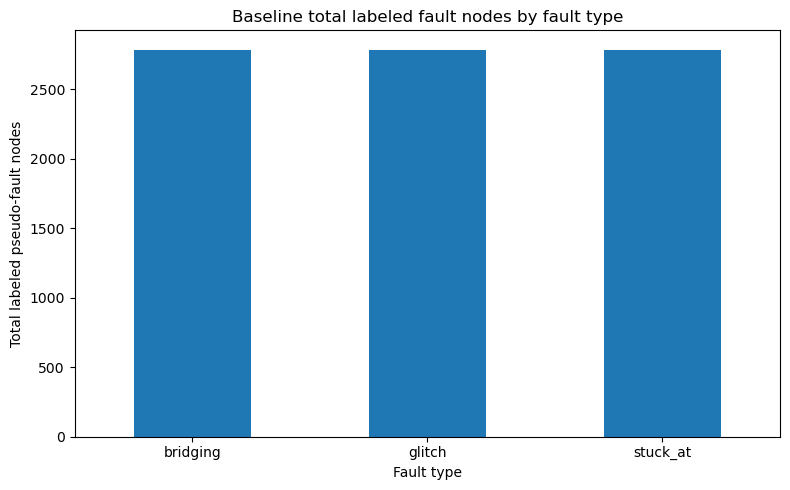

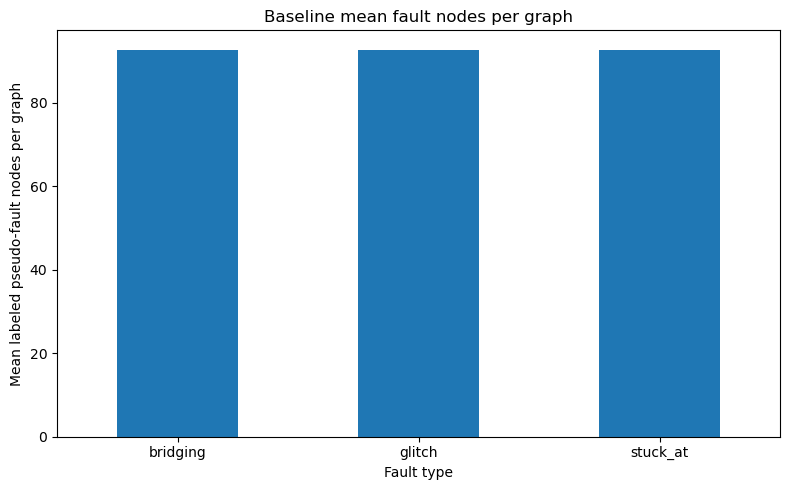

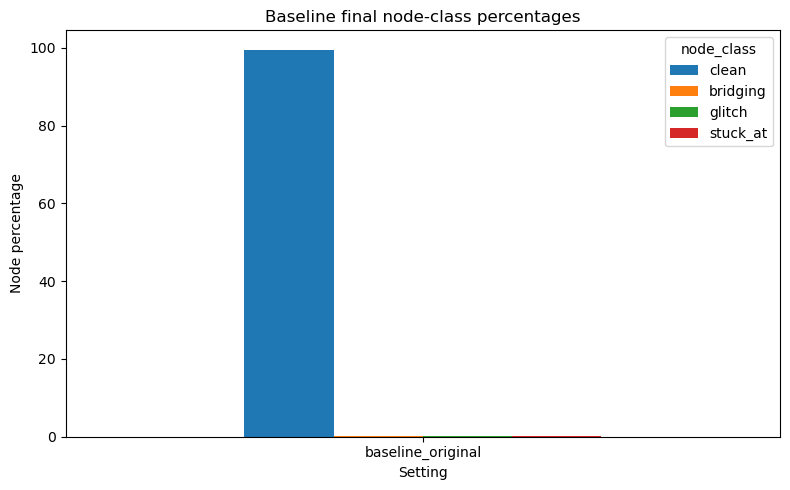


Found fault-number-sweep statistics. Creating baseline-vs-sweep comparison.

Comparison: node class counts, baseline versus fault-number sweep


,setting_label,clean,bridging,glitch,stuck_at
0,baseline_original,1709160,2783,2783,2781
1,100-500,1709160,8761,7969,7969
2,500-1000,1709160,21085,18082,18082
3,1000-2000,1709160,43167,32287,32287



Comparison: node class percentages, baseline versus fault-number sweep


,setting_label,clean,bridging,glitch,stuck_at
0,baseline_original,99.514005,0.162037,0.162037,0.161921
1,100-500,98.575490,0.505289,0.459611,0.459611
2,500-1000,96.759018,1.193665,1.023659,1.023659
3,1000-2000,94.070068,2.375859,1.777037,1.777037



Comparison: fault-type graph summary, baseline versus fault-number sweep


,setting_label,fault_type,graph_count,total_labeled_fault_nodes,mean_labeled_fault_nodes_per_graph,min_labeled_fault_nodes_per_graph,max_labeled_fault_nodes_per_graph,mean_fault_node_density_percent
0,baseline_original,clean,30,0,0.000000,0,0,0.000000
1,baseline_original,bridging,30,2783,92.766667,10,335,7.880318
2,baseline_original,glitch,30,2783,92.766667,10,335,7.880318
3,baseline_original,stuck_at,30,2781,92.700000,10,335,7.867517
4,100-500,clean,30,0,0.000000,0,0,0.000000
5,100-500,bridging,30,8761,292.033333,55,494,23.447001
6,100-500,glitch,30,7969,265.633333,11,494,20.244407
7,100-500,stuck_at,30,7969,265.633333,11,494,20.244407
8,500-1000,clean,30,0,0.000000,0,0,0.000000
9,500-1000,bridging,30,21085,702.833333,55,994,34.113170



Comparison: topology summary, baseline versus fault-number sweep


,setting_label,graph_count,unique_netlists,total_nodes,total_edges,total_labeled_fault_nodes,mean_nodes_per_graph,median_nodes_per_graph,mean_edges_per_graph,median_edges_per_graph,...,median_labeled_fault_nodes_per_graph,max_labeled_fault_nodes_per_graph,mean_fault_node_density_percent,mean_path_depth,max_path_depth,mean_dist_to_PO,max_dist_to_PO,max_fanout,range_min,range_max
0,baseline_original,120,30,1717507,2574726,8347,14312.558333,1969.0,21456.050,2673.5,...,86.0,335,5.907038,3.528398,39,14.431257,283,321,NaN,NaN
1,100-500,120,30,1733859,2583582,24699,14448.825000,2270.0,21529.850,2805.0,...,196.0,494,15.983954,3.383732,39,11.177613,281,5672,100.0,500.0
2,500-1000,120,30,1766409,2597562,57249,14720.075000,2342.0,21646.350,2885.5,...,536.5,994,22.367477,3.409613,44,8.927396,281,5672,500.0,1000.0
3,1000-2000,120,30,1816901,2623467,107741,15140.841667,3237.0,21862.225,3173.5,...,1170.0,1976,28.368366,3.614905,72,7.941025,281,5672,1000.0,2000.0


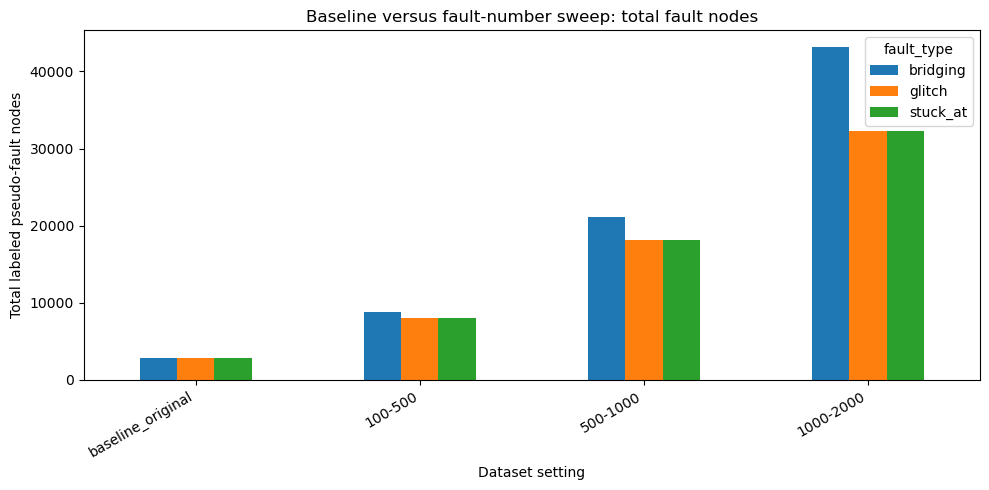

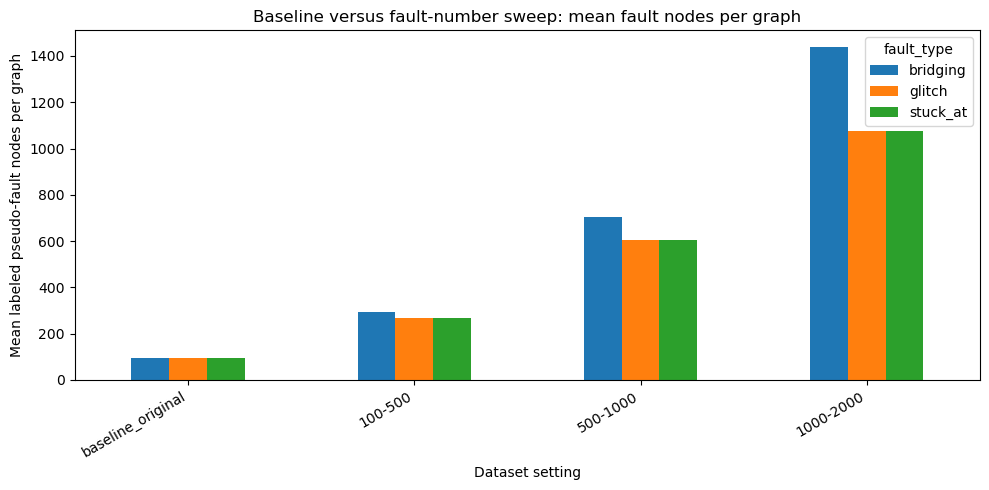

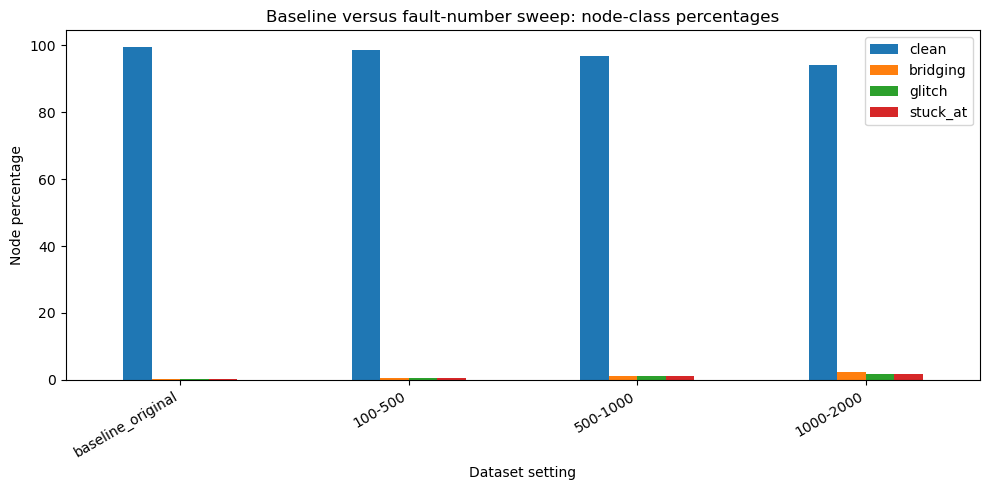


Reviewer-facing baseline statistics written to:
  baseline_original_statistics/baseline_class_balance_summary.csv
  baseline_original_statistics/baseline_faulttype_graph_summary.csv
  baseline_original_statistics/baseline_feature_summary_by_class.csv
  baseline_original_statistics/baseline_node_class_counts.csv
  baseline_original_statistics/baseline_node_class_percentages.csv
  baseline_original_statistics/baseline_per_graph_class_counts.csv
  baseline_original_statistics/baseline_per_graph_fault_counts.csv
  baseline_original_statistics/baseline_topology_summary.csv
  baseline_original_statistics/comparison_faulttype_graph_summary_baseline_vs_faultnumber.csv
  baseline_original_statistics/comparison_node_class_counts_baseline_vs_faultnumber.csv
  baseline_original_statistics/comparison_node_class_percentages_baseline_vs_faultnumber.csv
  baseline_original_statistics/comparison_topology_summary_baseline_vs_faultnumber.csv

Reviewer-facing baseline plots written to:
  baseline_origina

In [1]:
# ============================================================
# baseline_enhanced_dataset_statistics.py
#
# Statistics for the earlier baseline enhanced graph CSVs:
#   nodes_enhanced.csv
#   edges_enhanced.csv
#
# Optional fair-comparison mode:
#   If the fault-number-sweep statistics already exist under
#   fault_injection_fig_faultsweep/faultnumber_statistics/,
#   this script also creates combined comparison tables and plots:
#       baseline_original vs 100-500 vs 500-1000 vs 1000-2000
#
# Writes:
#   baseline_original_statistics/
#       baseline_node_class_counts.csv
#       baseline_node_class_percentages.csv
#       baseline_class_balance_summary.csv
#       baseline_faulttype_graph_summary.csv
#       baseline_topology_summary.csv
#       baseline_per_graph_class_counts.csv
#       baseline_per_graph_fault_counts.csv
#       baseline_feature_summary_by_class.csv
#       comparison_*.csv / comparison_*.png if sweep stats exist
# ============================================================


# ============================================================
# 1. Imports and configuration
# ============================================================

import re
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -------------------------
# Baseline input CSVs
# -------------------------
BASELINE_NODES_CSV = Path("nodes_enhanced.csv")
BASELINE_EDGES_CSV = Path("edges_enhanced.csv")

# Output folder for baseline statistics.
STATS_DIR = Path("baseline_original_statistics")

# Optional fault-number-sweep statistics folder generated by the previous script.
FAULT_SWEEP_STATS_DIR = Path("fault_injection_fig_faultsweep") / "faultnumber_statistics"

OVERWRITE_STATS_DIR = True

BASELINE_LABEL = "baseline_original"

FAULT_CLASS_ORDER = [
    "clean",
    "bridging",
    "glitch",
    "stuck_at",
]

FAULT_TYPE_ORDER = [
    "clean",
    "bridging",
    "glitch",
    "stuck_at",
]

NUMERIC_FEATURE_COLS = [
    "in_degree",
    "out_degree",
    "total_degree",
    "path_depth",
    "CC0_exact",
    "CC1_exact",
    "CO_exact",
    "dist_to_PO",
    "fanout",
    "fanout_norm",
    "gate_delay",
]


# ============================================================
# 2. Helper functions
# ============================================================

def normalize_source_file_name(name: str) -> str:
    """
    Normalize netlist filenames so baseline and fault-number-sweep
    graph rows can be compared.
    """
    base = Path(str(name)).name

    base = re.sub(r"^(stuck_at|glitch|bridging)_", "", base)
    base = re.sub(r"^k\d+_", "", base)

    return base


def make_node_class(row):
    """
    Final node-class interpretation used for node-level fault classification:
      - A node is a true stuck_at/glitch/bridging node only when
        fault_type is non-clean and label == 1.
      - All other nodes are clean.
    """
    if str(row["fault_type"]) != "clean" and int(row["label"]) == 1:
        return str(row["fault_type"])

    return "clean"


def ensure_numeric(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = (
                pd.to_numeric(df[c], errors="coerce")
                .replace([np.inf, -np.inf], np.nan)
                .fillna(0)
            )

    return df


def display_df(title: str, df: pd.DataFrame, max_rows: int = 30):
    print("\n" + title)
    print("=" * len(title))

    try:
        from IPython.display import display
        display(df.head(max_rows))
    except Exception:
        print(df.head(max_rows).to_string(index=False))


def sort_setting_labels(labels):
    """
    Order:
      baseline_original, then numeric ranges such as 100-500, 500-1000, ...
    """
    def key(label):
        label = str(label)

        if label == BASELINE_LABEL:
            return (-1, -1, label)

        m = re.match(r"^\s*(\d+)\s*[-_]\s*(\d+)\s*$", label)
        if m:
            return (int(m.group(1)), int(m.group(2)), label)

        return (10**12, 10**12, label)

    return sorted(labels, key=key)


# ============================================================
# 3. Load baseline enhanced CSVs
# ============================================================

if not BASELINE_NODES_CSV.exists():
    raise FileNotFoundError(f"Missing baseline nodes file: {BASELINE_NODES_CSV}")

if not BASELINE_EDGES_CSV.exists():
    raise FileNotFoundError(f"Missing baseline edges file: {BASELINE_EDGES_CSV}")

if STATS_DIR.exists():
    if OVERWRITE_STATS_DIR:
        shutil.rmtree(STATS_DIR)
    else:
        raise FileExistsError(
            f"{STATS_DIR} already exists. Set OVERWRITE_STATS_DIR=True to regenerate."
        )

STATS_DIR.mkdir(parents=True, exist_ok=True)

nodes = pd.read_csv(BASELINE_NODES_CSV)
edges = pd.read_csv(BASELINE_EDGES_CSV)

required_node_cols = [
    "netlist_file",
    "fault_type",
    "node_id",
    "gate_type",
    "label",
]

required_edge_cols = [
    "netlist_file",
    "fault_type",
    "src_node",
    "dst_node",
    "fan_out",
]

for c in required_node_cols:
    if c not in nodes.columns:
        raise ValueError(f"Missing node column {c} in {BASELINE_NODES_CSV}")

for c in required_edge_cols:
    if c not in edges.columns:
        raise ValueError(f"Missing edge column {c} in {BASELINE_EDGES_CSV}")

nodes["setting_label"] = BASELINE_LABEL
nodes["range_label"] = BASELINE_LABEL
nodes["netlist_file"] = nodes["netlist_file"].astype(str)
nodes["netlist_file_norm"] = nodes["netlist_file"].map(normalize_source_file_name)
nodes["fault_type"] = nodes["fault_type"].astype(str)
nodes["label"] = (
    pd.to_numeric(nodes["label"], errors="coerce")
    .fillna(0)
    .astype(int)
)
nodes["node_class"] = nodes.apply(make_node_class, axis=1)

edges["setting_label"] = BASELINE_LABEL
edges["range_label"] = BASELINE_LABEL
edges["netlist_file"] = edges["netlist_file"].astype(str)
edges["netlist_file_norm"] = edges["netlist_file"].map(normalize_source_file_name)
edges["fault_type"] = edges["fault_type"].astype(str)
edges["fan_out"] = (
    pd.to_numeric(edges["fan_out"], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

nodes = ensure_numeric(nodes, NUMERIC_FEATURE_COLS)

print("Loaded baseline enhanced graph data:")
print(f"  node rows: {len(nodes):,}")
print(f"  edge rows: {len(edges):,}")
print(f"  unique netlists: {nodes['netlist_file_norm'].nunique():,}")
print(f"  fault_type values: {sorted(nodes['fault_type'].unique().tolist())}")


# ============================================================
# 4. Baseline class-level node counts
# ============================================================

class_counts = (
    nodes
    .groupby(["setting_label", "node_class"], as_index=False)
    .size()
    .rename(columns={"size": "node_count"})
)

setting_total = len(nodes)

class_counts["total_nodes"] = setting_total
class_counts["node_percent"] = (
    100.0 * class_counts["node_count"] / max(1, setting_total)
)

available_classes = list(nodes["node_class"].dropna().unique())
class_order = [c for c in FAULT_CLASS_ORDER if c in available_classes]
class_order += sorted([c for c in available_classes if c not in class_order])

class_count_pivot = (
    class_counts
    .pivot_table(
        index="setting_label",
        columns="node_class",
        values="node_count",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(columns=class_order, fill_value=0)
)

class_percent_pivot = (
    class_counts
    .pivot_table(
        index="setting_label",
        columns="node_class",
        values="node_percent",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(columns=class_order, fill_value=0)
)

class_count_pivot.to_csv(STATS_DIR / "baseline_node_class_counts.csv")
class_percent_pivot.to_csv(STATS_DIR / "baseline_node_class_percentages.csv")

display_df(
    "Baseline node counts per final node class",
    class_count_pivot.reset_index(),
)

display_df(
    "Baseline node percentages per final node class",
    class_percent_pivot.reset_index(),
)


# ============================================================
# 5. Baseline class-balance summary
# ============================================================

class_balance = class_count_pivot.copy()

for c in class_order:
    if c not in class_balance.columns:
        class_balance[c] = 0

fault_classes = [c for c in class_order if c != "clean"]

class_balance["total_nodes"] = class_balance[class_order].sum(axis=1)
class_balance["total_fault_nodes"] = (
    class_balance[fault_classes].sum(axis=1)
    if fault_classes
    else 0
)
class_balance["fault_node_percent"] = (
    100.0 * class_balance["total_fault_nodes"] / class_balance["total_nodes"].clip(lower=1)
)

if "clean" in class_balance.columns:
    class_balance["clean_to_fault_ratio"] = (
        class_balance["clean"] / class_balance["total_fault_nodes"].replace(0, np.nan)
    )
else:
    class_balance["clean_to_fault_ratio"] = np.nan

class_balance = class_balance.reset_index()
class_balance.to_csv(STATS_DIR / "baseline_class_balance_summary.csv", index=False)

display_df(
    "Baseline class-balance summary",
    class_balance,
)


# ============================================================
# 6. Baseline per-graph statistics
# ============================================================

node_graph_group_cols = [
    "setting_label",
    "netlist_file",
    "netlist_file_norm",
    "fault_type",
]

graph_node_stats = (
    nodes
    .groupby(node_graph_group_cols, as_index=False)
    .agg(
        nodes=("node_id", "count"),
        labeled_fault_nodes=("label", "sum"),
        final_clean_nodes=("node_class", lambda s: int((s == "clean").sum())),
        final_bridging_nodes=("node_class", lambda s: int((s == "bridging").sum())),
        final_glitch_nodes=("node_class", lambda s: int((s == "glitch").sum())),
        final_stuck_at_nodes=("node_class", lambda s: int((s == "stuck_at").sum())),
        mean_path_depth=("path_depth", "mean"),
        max_path_depth=("path_depth", "max"),
        mean_dist_to_PO=("dist_to_PO", "mean"),
        max_dist_to_PO=("dist_to_PO", "max"),
        mean_fanout=("fanout", "mean"),
        max_fanout=("fanout", "max"),
        mean_CC0_exact=("CC0_exact", "mean"),
        mean_CC1_exact=("CC1_exact", "mean"),
        mean_CO_exact=("CO_exact", "mean"),
    )
)

edge_graph_group_cols = [
    "setting_label",
    "netlist_file",
    "netlist_file_norm",
    "fault_type",
]

graph_edge_stats = (
    edges
    .groupby(edge_graph_group_cols, as_index=False)
    .agg(
        edges=("src_node", "count"),
        mean_edge_fan_out=("fan_out", "mean"),
        max_edge_fan_out=("fan_out", "max"),
    )
)

graph_stats = graph_node_stats.merge(
    graph_edge_stats,
    on=edge_graph_group_cols,
    how="left",
)

graph_stats["edges"] = graph_stats["edges"].fillna(0).astype(int)
graph_stats["mean_edge_fan_out"] = graph_stats["mean_edge_fan_out"].fillna(0)
graph_stats["max_edge_fan_out"] = graph_stats["max_edge_fan_out"].fillna(0)

graph_stats["fault_node_density_percent"] = (
    100.0 * graph_stats["labeled_fault_nodes"] / graph_stats["nodes"].clip(lower=1)
)

graph_stats.to_csv(STATS_DIR / "baseline_per_graph_fault_counts.csv", index=False)

display_df(
    "Baseline per-graph fault-node count examples",
    graph_stats[
        [
            "netlist_file_norm",
            "fault_type",
            "nodes",
            "edges",
            "labeled_fault_nodes",
            "fault_node_density_percent",
        ]
    ],
    max_rows=20,
)


# ============================================================
# 7. Baseline summary by fault type
# ============================================================

available_fault_types = list(graph_stats["fault_type"].dropna().unique())
fault_type_order = [f for f in FAULT_TYPE_ORDER if f in available_fault_types]
fault_type_order += sorted([f for f in available_fault_types if f not in fault_type_order])

faulttype_summary = (
    graph_stats
    .groupby(["setting_label", "fault_type"], as_index=False)
    .agg(
        graph_count=("netlist_file_norm", "count"),
        unique_netlists=("netlist_file_norm", "nunique"),
        total_nodes=("nodes", "sum"),
        total_edges=("edges", "sum"),
        total_labeled_fault_nodes=("labeled_fault_nodes", "sum"),
        mean_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "mean"),
        median_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "median"),
        min_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "min"),
        max_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "max"),
        std_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "std"),
        mean_fault_node_density_percent=("fault_node_density_percent", "mean"),
        median_fault_node_density_percent=("fault_node_density_percent", "median"),
        mean_nodes_per_graph=("nodes", "mean"),
        mean_edges_per_graph=("edges", "mean"),
        mean_path_depth=("mean_path_depth", "mean"),
        max_path_depth=("max_path_depth", "max"),
        mean_dist_to_PO=("mean_dist_to_PO", "mean"),
        max_dist_to_PO=("max_dist_to_PO", "max"),
        mean_fanout=("mean_fanout", "mean"),
        max_fanout=("max_fanout", "max"),
    )
)

faulttype_summary["std_labeled_fault_nodes_per_graph"] = (
    faulttype_summary["std_labeled_fault_nodes_per_graph"].fillna(0)
)

faulttype_summary["fault_type_order"] = faulttype_summary["fault_type"].map(
    lambda x: fault_type_order.index(x) if x in fault_type_order else 999
)

faulttype_summary = (
    faulttype_summary
    .sort_values(["fault_type_order", "fault_type"])
    .drop(columns=["fault_type_order"])
    .reset_index(drop=True)
)

faulttype_summary.to_csv(STATS_DIR / "baseline_faulttype_graph_summary.csv", index=False)

display_df(
    "Baseline summary by fault type",
    faulttype_summary,
)


# ============================================================
# 8. Overall baseline topology summary
# ============================================================

topology_summary = (
    graph_stats
    .groupby(["setting_label"], as_index=False)
    .agg(
        graph_count=("netlist_file_norm", "count"),
        unique_netlists=("netlist_file_norm", "nunique"),
        total_nodes=("nodes", "sum"),
        total_edges=("edges", "sum"),
        total_labeled_fault_nodes=("labeled_fault_nodes", "sum"),
        mean_nodes_per_graph=("nodes", "mean"),
        median_nodes_per_graph=("nodes", "median"),
        mean_edges_per_graph=("edges", "mean"),
        median_edges_per_graph=("edges", "median"),
        mean_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "mean"),
        median_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "median"),
        max_labeled_fault_nodes_per_graph=("labeled_fault_nodes", "max"),
        mean_fault_node_density_percent=("fault_node_density_percent", "mean"),
        mean_path_depth=("mean_path_depth", "mean"),
        max_path_depth=("max_path_depth", "max"),
        mean_dist_to_PO=("mean_dist_to_PO", "mean"),
        max_dist_to_PO=("max_dist_to_PO", "max"),
        max_fanout=("max_fanout", "max"),
    )
)

topology_summary.to_csv(STATS_DIR / "baseline_topology_summary.csv", index=False)

display_df(
    "Overall baseline topology summary",
    topology_summary,
)


# ============================================================
# 9. Per-graph class-count matrix
# ============================================================

per_graph_class_counts = (
    nodes
    .groupby(
        [
            "setting_label",
            "netlist_file",
            "netlist_file_norm",
            "fault_type",
            "node_class",
        ],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "node_count"})
)

per_graph_class_counts_pivot = (
    per_graph_class_counts
    .pivot_table(
        index=[
            "setting_label",
            "netlist_file",
            "netlist_file_norm",
            "fault_type",
        ],
        columns="node_class",
        values="node_count",
        fill_value=0,
        aggfunc="sum",
    )
    .reset_index()
)

for c in class_order:
    if c not in per_graph_class_counts_pivot.columns:
        per_graph_class_counts_pivot[c] = 0

per_graph_class_counts_pivot["total_nodes"] = (
    per_graph_class_counts_pivot[class_order].sum(axis=1)
)

per_graph_class_counts_pivot.to_csv(STATS_DIR / "baseline_per_graph_class_counts.csv", index=False)

display_df(
    "Baseline per-graph class-count matrix examples",
    per_graph_class_counts_pivot,
    max_rows=20,
)


# ============================================================
# 10. Feature summaries by final node class
# ============================================================

feature_summary = (
    nodes
    .groupby(["setting_label", "node_class"])[NUMERIC_FEATURE_COLS]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

feature_summary.columns = [
    f"{feature}_{stat}"
    for feature, stat in feature_summary.columns
]

feature_summary = (
    feature_summary
    .reset_index()
    .sort_values(["setting_label", "node_class"])
    .reset_index(drop=True)
)

feature_summary.to_csv(STATS_DIR / "baseline_feature_summary_by_class.csv", index=False)

display_df(
    "Baseline enhanced feature summary by final node class",
    feature_summary,
    max_rows=20,
)


# ============================================================
# 11. Baseline plots
# ============================================================

fault_only_summary = faulttype_summary[
    faulttype_summary["fault_type"] != "clean"
].copy()

plt.figure(figsize=(8, 5))
fault_totals = fault_only_summary.set_index("fault_type")["total_labeled_fault_nodes"]
fault_totals = fault_totals.reindex([f for f in fault_type_order if f != "clean"]).dropna()
fault_totals.plot(kind="bar")
plt.xlabel("Fault type")
plt.ylabel("Total labeled pseudo-fault nodes")
plt.title("Baseline total labeled fault nodes by fault type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(STATS_DIR / "baseline_total_labeled_fault_nodes_by_fault_type.png", dpi=200)
plt.show()


plt.figure(figsize=(8, 5))
fault_mean = fault_only_summary.set_index("fault_type")["mean_labeled_fault_nodes_per_graph"]
fault_mean = fault_mean.reindex([f for f in fault_type_order if f != "clean"]).dropna()
fault_mean.plot(kind="bar")
plt.xlabel("Fault type")
plt.ylabel("Mean labeled pseudo-fault nodes per graph")
plt.title("Baseline mean fault nodes per graph")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(STATS_DIR / "baseline_mean_fault_nodes_per_graph.png", dpi=200)
plt.show()


plt.figure(figsize=(8, 5))
class_percent_pivot.plot(kind="bar", ax=plt.gca())
plt.xlabel("Setting")
plt.ylabel("Node percentage")
plt.title("Baseline final node-class percentages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(STATS_DIR / "baseline_node_class_percentages.png", dpi=200)
plt.show()


# ============================================================
# 12. Optional comparison with fault-number sweep
# ============================================================

comparison_available = FAULT_SWEEP_STATS_DIR.exists()

if comparison_available:
    required_files = [
        FAULT_SWEEP_STATS_DIR / "range_node_class_counts.csv",
        FAULT_SWEEP_STATS_DIR / "range_node_class_percentages.csv",
        FAULT_SWEEP_STATS_DIR / "range_class_balance_summary.csv",
        FAULT_SWEEP_STATS_DIR / "range_faulttype_graph_summary.csv",
        FAULT_SWEEP_STATS_DIR / "range_topology_summary.csv",
    ]

    missing_files = [p for p in required_files if not p.exists()]

    if missing_files:
        warnings.warn(
            "Fault-number-sweep statistics folder exists, but some expected "
            f"CSV files are missing: {missing_files}. Skipping comparison."
        )
        comparison_available = False

if comparison_available:
    print("\nFound fault-number-sweep statistics. Creating baseline-vs-sweep comparison.")

    # -------------------------
    # Class-count comparison
    # -------------------------
    sweep_class_counts = pd.read_csv(
        FAULT_SWEEP_STATS_DIR / "range_node_class_counts.csv"
    )

    # The sweep CSV is typically a pivot table with range_label as the first column.
    if "range_label" not in sweep_class_counts.columns:
        first_col = sweep_class_counts.columns[0]
        sweep_class_counts = sweep_class_counts.rename(columns={first_col: "setting_label"})
    else:
        sweep_class_counts = sweep_class_counts.rename(columns={"range_label": "setting_label"})

    baseline_counts_for_compare = class_count_pivot.reset_index().rename(
        columns={"setting_label": "setting_label"}
    )

    comparison_class_counts = pd.concat(
        [
            baseline_counts_for_compare,
            sweep_class_counts,
        ],
        ignore_index=True,
        sort=False,
    ).fillna(0)

    setting_order = sort_setting_labels(comparison_class_counts["setting_label"].unique().tolist())

    comparison_class_counts = (
        comparison_class_counts
        .set_index("setting_label")
        .reindex(setting_order)
        .reset_index()
    )

    comparison_class_counts.to_csv(
        STATS_DIR / "comparison_node_class_counts_baseline_vs_faultnumber.csv",
        index=False,
    )

    display_df(
        "Comparison: node class counts, baseline versus fault-number sweep",
        comparison_class_counts,
    )

    # -------------------------
    # Class-percent comparison
    # -------------------------
    sweep_class_percent = pd.read_csv(
        FAULT_SWEEP_STATS_DIR / "range_node_class_percentages.csv"
    )

    if "range_label" not in sweep_class_percent.columns:
        first_col = sweep_class_percent.columns[0]
        sweep_class_percent = sweep_class_percent.rename(columns={first_col: "setting_label"})
    else:
        sweep_class_percent = sweep_class_percent.rename(columns={"range_label": "setting_label"})

    baseline_percent_for_compare = class_percent_pivot.reset_index().rename(
        columns={"setting_label": "setting_label"}
    )

    comparison_class_percent = pd.concat(
        [
            baseline_percent_for_compare,
            sweep_class_percent,
        ],
        ignore_index=True,
        sort=False,
    ).fillna(0)

    comparison_class_percent = (
        comparison_class_percent
        .set_index("setting_label")
        .reindex(setting_order)
        .reset_index()
    )

    comparison_class_percent.to_csv(
        STATS_DIR / "comparison_node_class_percentages_baseline_vs_faultnumber.csv",
        index=False,
    )

    display_df(
        "Comparison: node class percentages, baseline versus fault-number sweep",
        comparison_class_percent,
    )

    # -------------------------
    # Fault-type graph summary comparison
    # -------------------------
    sweep_faulttype = pd.read_csv(
        FAULT_SWEEP_STATS_DIR / "range_faulttype_graph_summary.csv"
    )

    sweep_faulttype = sweep_faulttype.rename(columns={"range_label": "setting_label"})

    baseline_faulttype_for_compare = faulttype_summary.copy()
    baseline_faulttype_for_compare["range_min"] = np.nan
    baseline_faulttype_for_compare["range_max"] = np.nan

    comparison_faulttype = pd.concat(
        [
            baseline_faulttype_for_compare,
            sweep_faulttype,
        ],
        ignore_index=True,
        sort=False,
    )

    comparison_faulttype["setting_sort"] = comparison_faulttype["setting_label"].map(
        lambda x: setting_order.index(x) if x in setting_order else 999
    )

    comparison_faulttype["fault_type_sort"] = comparison_faulttype["fault_type"].map(
        lambda x: fault_type_order.index(x) if x in fault_type_order else 999
    )

    comparison_faulttype = (
        comparison_faulttype
        .sort_values(["setting_sort", "fault_type_sort", "fault_type"])
        .drop(columns=["setting_sort", "fault_type_sort"])
        .reset_index(drop=True)
    )

    comparison_faulttype.to_csv(
        STATS_DIR / "comparison_faulttype_graph_summary_baseline_vs_faultnumber.csv",
        index=False,
    )

    display_df(
        "Comparison: fault-type graph summary, baseline versus fault-number sweep",
        comparison_faulttype[
            [
                "setting_label",
                "fault_type",
                "graph_count",
                "total_labeled_fault_nodes",
                "mean_labeled_fault_nodes_per_graph",
                "min_labeled_fault_nodes_per_graph",
                "max_labeled_fault_nodes_per_graph",
                "mean_fault_node_density_percent",
            ]
        ],
    )

    # -------------------------
    # Topology comparison
    # -------------------------
    sweep_topology = pd.read_csv(
        FAULT_SWEEP_STATS_DIR / "range_topology_summary.csv"
    )

    sweep_topology = sweep_topology.rename(columns={"range_label": "setting_label"})

    baseline_topology_for_compare = topology_summary.copy()
    baseline_topology_for_compare["range_min"] = np.nan
    baseline_topology_for_compare["range_max"] = np.nan

    comparison_topology = pd.concat(
        [
            baseline_topology_for_compare,
            sweep_topology,
        ],
        ignore_index=True,
        sort=False,
    )

    comparison_topology["setting_sort"] = comparison_topology["setting_label"].map(
        lambda x: setting_order.index(x) if x in setting_order else 999
    )

    comparison_topology = (
        comparison_topology
        .sort_values(["setting_sort"])
        .drop(columns=["setting_sort"])
        .reset_index(drop=True)
    )

    comparison_topology.to_csv(
        STATS_DIR / "comparison_topology_summary_baseline_vs_faultnumber.csv",
        index=False,
    )

    display_df(
        "Comparison: topology summary, baseline versus fault-number sweep",
        comparison_topology,
    )

    # -------------------------
    # Comparison plots
    # -------------------------
    fault_only_comparison = comparison_faulttype[
        comparison_faulttype["fault_type"] != "clean"
    ].copy()

    total_fault_pivot = (
        fault_only_comparison
        .pivot_table(
            index="setting_label",
            columns="fault_type",
            values="total_labeled_fault_nodes",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(index=setting_order)
    )

    plt.figure(figsize=(10, 5))
    total_fault_pivot.plot(kind="bar", ax=plt.gca())
    plt.xlabel("Dataset setting")
    plt.ylabel("Total labeled pseudo-fault nodes")
    plt.title("Baseline versus fault-number sweep: total fault nodes")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(
        STATS_DIR / "comparison_total_labeled_fault_nodes_baseline_vs_faultnumber.png",
        dpi=200,
    )
    plt.show()

    mean_fault_pivot = (
        fault_only_comparison
        .pivot_table(
            index="setting_label",
            columns="fault_type",
            values="mean_labeled_fault_nodes_per_graph",
            aggfunc="mean",
            fill_value=0,
        )
        .reindex(index=setting_order)
    )

    plt.figure(figsize=(10, 5))
    mean_fault_pivot.plot(kind="bar", ax=plt.gca())
    plt.xlabel("Dataset setting")
    plt.ylabel("Mean labeled pseudo-fault nodes per graph")
    plt.title("Baseline versus fault-number sweep: mean fault nodes per graph")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(
        STATS_DIR / "comparison_mean_fault_nodes_per_graph_baseline_vs_faultnumber.png",
        dpi=200,
    )
    plt.show()

    comparison_percent_plot = comparison_class_percent.set_index("setting_label")

    plt.figure(figsize=(10, 5))
    comparison_percent_plot.plot(kind="bar", ax=plt.gca())
    plt.xlabel("Dataset setting")
    plt.ylabel("Node percentage")
    plt.title("Baseline versus fault-number sweep: node-class percentages")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(
        STATS_DIR / "comparison_node_class_percentages_baseline_vs_faultnumber.png",
        dpi=200,
    )
    plt.show()

else:
    print(
        "\nFault-number-sweep statistics folder was not found or incomplete. "
        "Baseline-only statistics were generated."
    )


# ============================================================
# 13. Final reviewer-facing printout
# ============================================================

print("\nReviewer-facing baseline statistics written to:")
print("==============================================")
for p in sorted(STATS_DIR.glob("*.csv")):
    print(" ", p)

print("\nReviewer-facing baseline plots written to:")
print("==========================================")
for p in sorted(STATS_DIR.glob("*.png")):
    print(" ", p)

print("\nCompact baseline class counts:")
print("==============================")
print(class_count_pivot.to_string())

print("\nCompact baseline class balance:")
print("===============================")
print(class_balance.to_string(index=False))

print("\nCompact baseline fault-type summary:")
print("====================================")
print(
    faulttype_summary[
        [
            "fault_type",
            "graph_count",
            "total_labeled_fault_nodes",
            "mean_labeled_fault_nodes_per_graph",
            "min_labeled_fault_nodes_per_graph",
            "max_labeled_fault_nodes_per_graph",
            "mean_fault_node_density_percent",
        ]
    ].to_string(index=False)
)

print("\nBaseline statistics generation complete.")